![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/visual-nlp-workshop/blob/master/jupyter/SparkOcrDocDataLoaderPipelines.ipynb)

# Example of Doc Data Loader Pretrained Pipelines
Pretrained Pipelines can be considered predefined recipes in the form of Visual NLP pipelines, these recipes come with a set of stages and parameters that help to accomplish specific tasks.</br> 
In these examples, we will explore a family of pipelines that can ingest documents in multiple formats(images, digital PDFs, scanned PDFs). Different inputs are detected and routed to the best model which can return the best possible accuracy while delivering the best performance at the same time.</br>
Pipelines return tables and text.

In [6]:
secret = ""
license = ""
version = secret.split("-")[0]
spark_ocr_jar_path = "./"

## Initialization of spark session

In [7]:
from pyspark.sql import SparkSession
from sparkocr import start
import sys
import os

if license:
    os.environ['JSL_OCR_LICENSE'] = license

spark = start(secret=secret, jar_path=spark_ocr_jar_path, use_gpu=True)
spark

Spark version: 3.4.1
Spark NLP version: 7.0.0
Spark NLP for Healthcare version: 6.4.1
Spark OCR version: 7.0.0



In [8]:
import pkg_resources
from sparkocr.transformers import *
from sparkocr.utils import *
from sparkocr.enums import *

from pyspark.ml import PipelineModel, Pipeline
import pyspark.sql.functions as f
from sparkocr.utils.helpers import cluster

## Sample Data
In these examples, we will be dealing with multiple input formats. We'll start with images, let's take a look,


    Image #0:
    Origin: file:/home/ubuntu/trainings_october_2026/mixed_formats/rotated.png
    Resolution: 72 dpi
    Width: 1000 px
    Height: 2000 px
    Mode: 5
    Number of channels: 3


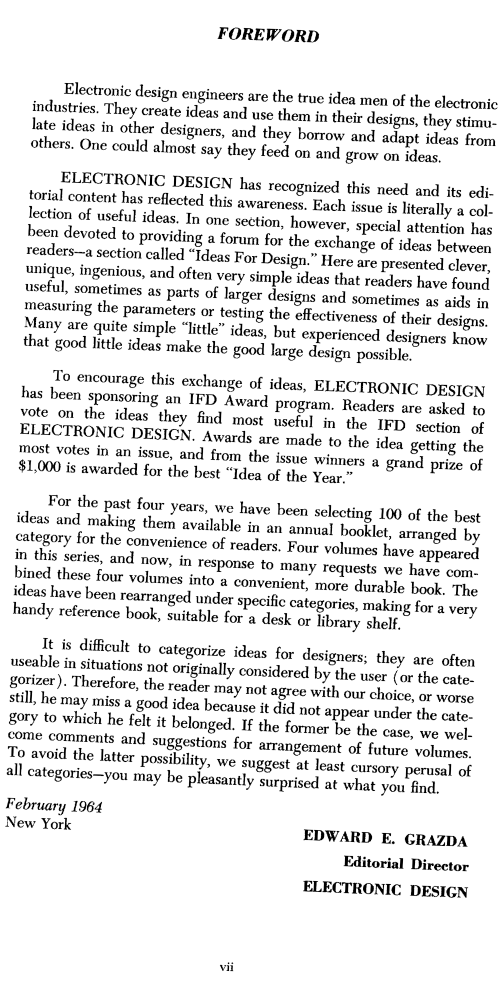

In [4]:
from sparkocr.utils import display_image

images_path = "./mixed_formats/*.png"
images_df = spark.read.format("binaryFile").load(images_path).sort("path")

display_images(BinaryToImage().setImageType(ImageType.TYPE_3BYTE_BGR).transform(images_df), "image")

Now the turn for the PDFs

26/10/09 13:25:01 WARN PDType1Font: Using fallback font LiberationSans for base font Symbol
26/10/09 13:25:01 WARN PDType1Font: Using fallback font LiberationSans for base font ZapfDingbats



    Image #0:
    Origin: file:/home/ubuntu/trainings_october_2026/mixed_formats/h_and_p.pdf
    Resolution: 300 dpi
    Width: 2480 px
    Height: 3507 px
    Mode: 10
    Number of channels: 1


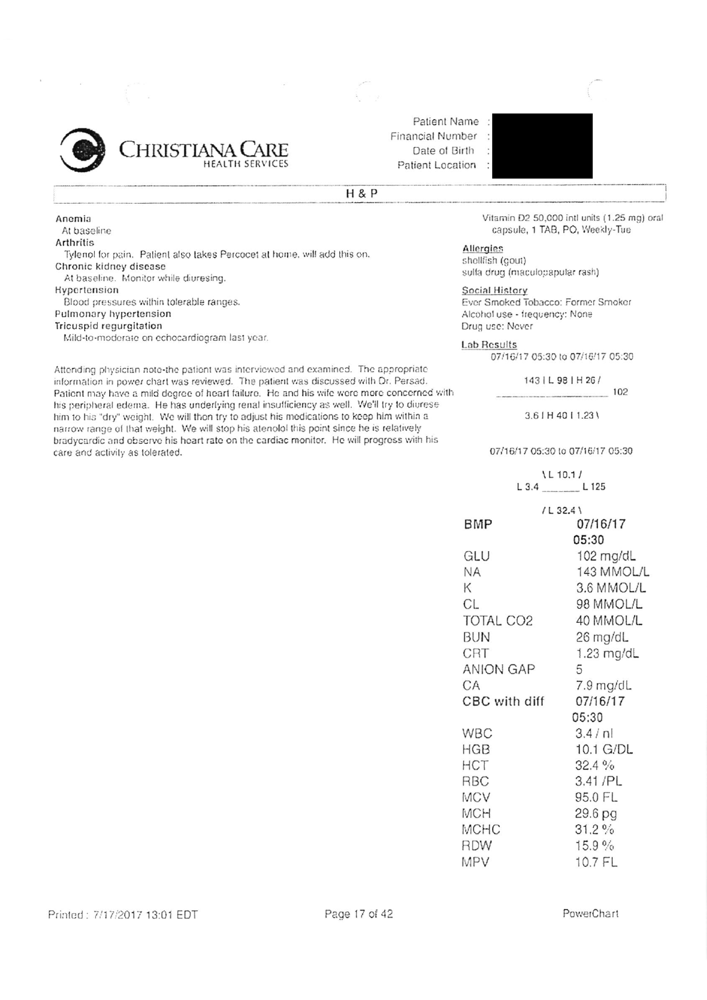


    Image #1:
    Origin: file:/home/ubuntu/trainings_october_2026/mixed_formats/PDF_Deid_Deidentification_0.pdf
    Resolution: 300 dpi
    Width: 2480 px
    Height: 3507 px
    Mode: 10
    Number of channels: 1


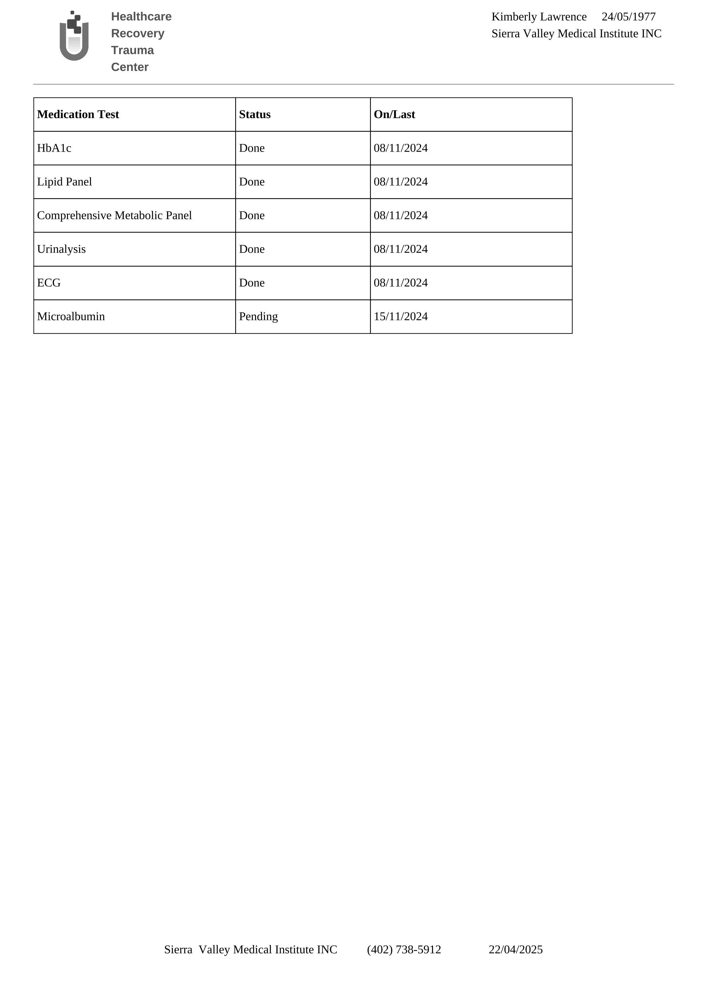


    Image #2:
    Origin: file:/home/ubuntu/trainings_october_2026/mixed_formats/PDF_Deid_Deidentification_0.pdf
    Resolution: 300 dpi
    Width: 2480 px
    Height: 3507 px
    Mode: 10
    Number of channels: 1


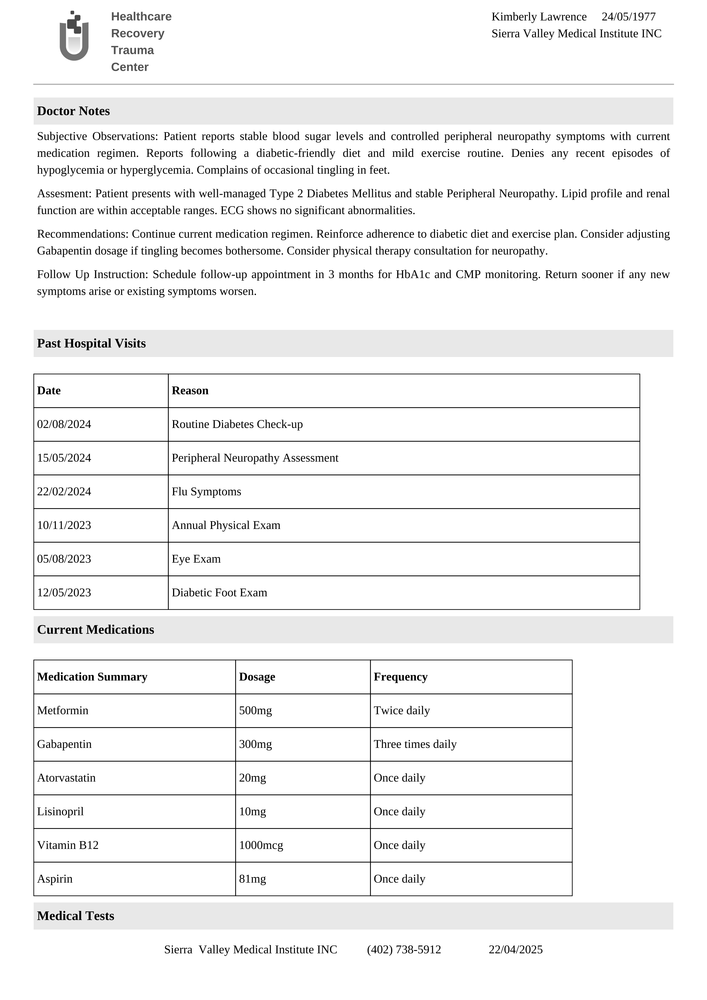


    Image #3:
    Origin: file:/home/ubuntu/trainings_october_2026/mixed_formats/report.pdf
    Resolution: 300 dpi
    Width: 4254 px
    Height: 3770 px
    Mode: 10
    Number of channels: 1


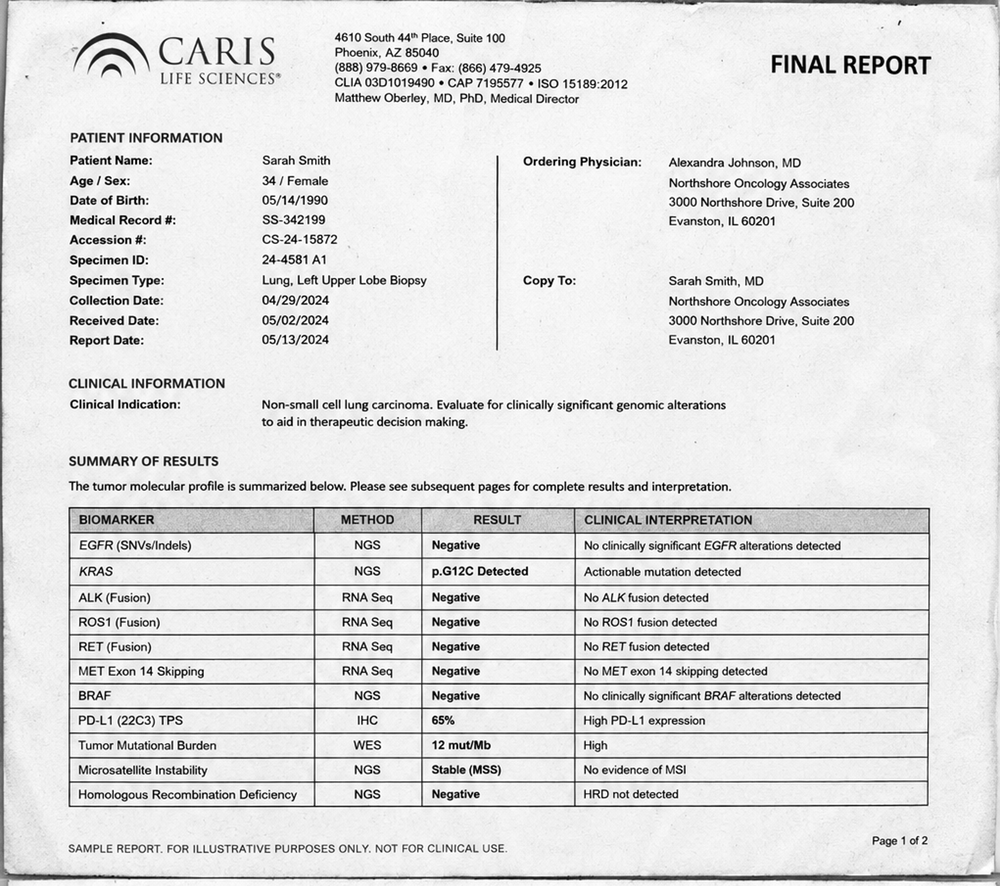


    Image #4:
    Origin: file:/home/ubuntu/trainings_october_2026/mixed_formats/forms.pdf
    Resolution: 300 dpi
    Width: 2480 px
    Height: 3507 px
    Mode: 10
    Number of channels: 1


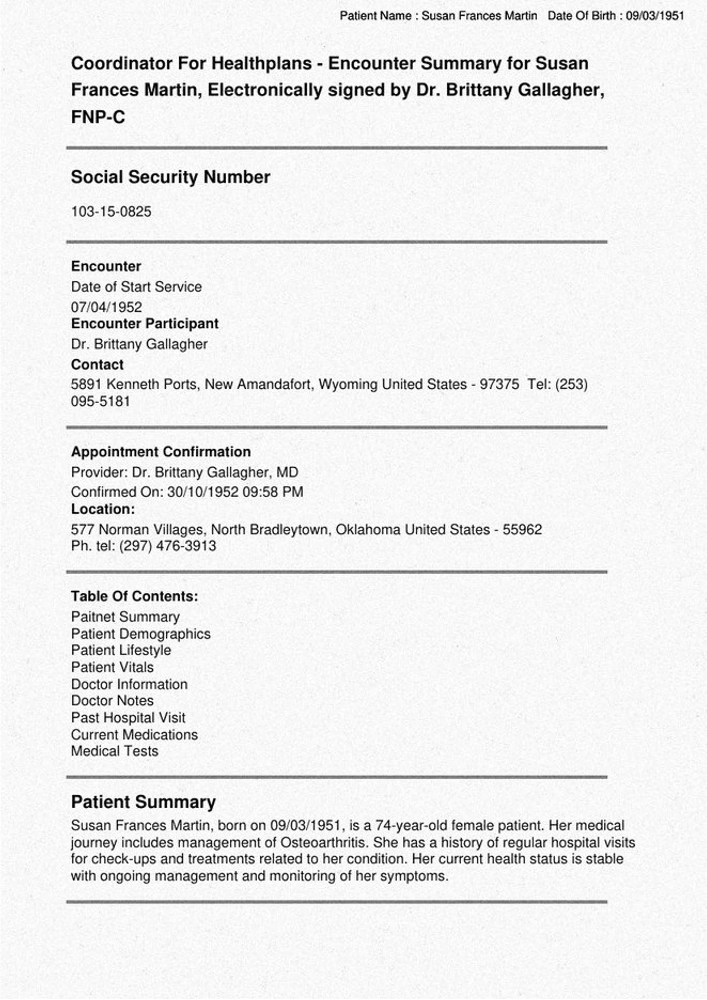

In [5]:
from sparkocr.utils import display_pdf

pdfs_path = "./mixed_formats/*.pdf"
pdfs_df = spark.read.format("binaryFile").load(pdfs_path).sort("path")

from sparkocr.utils import display_pdf_file
display_pdf(pdfs_df)

# Pretrained Pipelines
## Table Pipelines

### doc_data_loader_digital_hybrid_tables_vlm1
In this simple pipeline we can use the predefined pipeline to handle a mix of scanned(containing images), digital PDFs(containing digital text), and images as well. The output is going to be returned in a Dataframe column(`merged_text`), and it will contain texts coming from all sources.</br>
You could even have a single PDF file with a mix of digital and scanned pages.</br>


In [6]:
from pyspark.ml import PipelineModel
from sparkocr.pretrained import *

pipeline = PretrainedPipeline('doc_data_loader_digital_hybrid_tables_vlm1', 'en', 'clinical/ocr')

doc_data_loader_digital_hybrid_tables_vlm1 download started this may take some time.
Approx size to download 1.5 GB
[OK!]


### [Optional] Performance Tricks

In [ ]:
# Put a limit on image size.
pipeline.model.stages[2].setMaxImageWidth(1250)
# Send the model to GPU
pipeline.model.stages[-3].setNGpuLayers(99)

### Call the pipeline
We are listing the 'mixed_pdfs' folder, that one contains two PDF files, one is scanned and the other is digital. You can open them yourself and verify.

In [6]:
all_files_path = './mixed_formats/*'
all_files_df = spark.read.format("binaryFile").load(all_files_path).cache()

result = pipeline.transform(all_files_df).cache()

### Results
Note: to avoid truncation, using collect() on just the text column,
`merged_text` -> column collecting results from multiple pipeline components(digital text, VLM, OCR).

In [32]:
for t in result.select("merged_text").collect():
    print(t.merged_text.replace("\\n", "\n"))
    print("*"*20)

FOREWORD
Electronic design engineers are the true idea men of the electronic
industries. They create ideas and use them in their designs, they stimu-
late ideas in other designers, and they borrow and adapt ideas from
others. One could almost say they feed on and grow on ideas.
ELECTRONIC DESIGN has recognized this need and its edi-
torial content has reflected this awareness. Each issue is literally a col-
lection of useful ideas. In one section, however, special attention has
been devoted to providing a forum for the exchange of ideas between
readers—a section called “Ideas For Design.” Here are presented clever,
unique, ingenious, and often very simple ideas that readers have found
useful, sometimes as parts of larger designs and sometimes as aids in
measuring the parameters or testing the effectiveness of their designs.
Many are quite simple “little” ideas, but experienced designers know
that good little ideas make the good large design possible.

To encourage this exchange of idea

### doc_data_loader_digital_hybrid_tables_vlm2

In [5]:
from sparkocr.pretrained import PretrainedPipeline
pipeline = PretrainedPipeline('doc_data_loader_digital_hybrid_tables_vlm2', 'en', 'clinical/ocr')

# disable some ugly messages.
pipeline.model.stages[1].setIgnoreNonPdf(True)
pipeline.model.stages[2].setMaxImageWidth(1050)
pipeline.model.stages[-3].setNGpuLayers(99)


result = pipeline.transform(all_files_df).cache()

for t in result.select("merged_text").collect():
    print(t.merged_text.replace("\\n", "\n"))
    print("*"*20)

doc_data_loader_digital_hybrid_tables_vlm2 download started this may take some time.
Approx size to download 1.3 GB
[ | ]

26/07/02 19:05:33 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
26/07/02 19:05:33 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.


doc_data_loader_digital_hybrid_tables_vlm2 download started this may take some time.
Approximate size to download 1.3 GB
Download done! Loading the resource.


Traceback (most recent call last):
  File "/home/jose/spark-ocr/sparkocr/lib/python3.12/site-packages/pyspark/serializers.py", line 437, in dumps
    return cloudpickle.dumps(obj, pickle_protocol)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jose/spark-ocr/sparkocr/lib/python3.12/site-packages/pyspark/cloudpickle/cloudpickle_fast.py", line 73, in dumps
    cp.dump(obj)
  File "/home/jose/spark-ocr/sparkocr/lib/python3.12/site-packages/pyspark/cloudpickle/cloudpickle_fast.py", line 563, in dump
    return Pickler.dump(self, obj)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jose/spark-ocr/sparkocr/lib/python3.12/site-packages/pyspark/cloudpickle/cloudpickle_fast.py", line 653, in reducer_override
    return self._function_reduce(obj)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jose/spark-ocr/sparkocr/lib/python3.12/site-packages/pyspark/cloudpickle/cloudpickle_fast.py", line 526, in _function_reduce
    return self._dynamic_function_reduce(obj)
           

[ / ]

...

doc_data_loader_digital_hybrid_tables_vlm2 download started this may take some time.
Approximate size to download 1.3 GB
Download done! Loading the resource.
[ — ]Extracted 'libjllama.so' to '/tmp/libjllama.so'
[ \ ]

ggml_cuda_init: found 1 CUDA devices (Total VRAM: 7807 MiB):
  Device 0: NVIDIA GeForce RTX 4070 Laptop GPU, compute capability 8.9, VMM: yes, VRAM: 7807 MiB
                                                                                

[OK!]


[Stage 28:====================================================>   (15 + 1) / 16]

"
## PATHOGENIC VARIANTS

| GENE | VARIANT | EFFECT | VAF (%) | CLINICAL SIGNIFICANCE |
| :--- | :--- | :--- | :--- | :--- |
| KRA5 | c.34G>T (p.G12C) | Missense | 38% | Oncogenic |
| TP53 | c.818G>A (p.R273H) | Missense | 44% | Pathogenic |
| STK11 | c.1060T>C (p.F354L) | Missense | 29% | Pathogenic |
| KEAP1 | c.1154G>A (p.G385D) | Missense | 27% | Likely Pathogenic |

## GENES TESTED (Selected)

| GENE | RESULT | GENE | RESULT |
| :--- | :--- | :--- | :--- |
| AKT1 | Not Detected | NTRK2 | Fusion Not Detected |
| BRCA1 | Not Detected | NTRK3 | Fusion Not Detected |
| BRCA2 | Not Detected | RET | Fusion Not Detected |
| CDKN2A | Not Detected | BRAF | Not Detected |
| ERB82 (HER2) | Not Detected | MET Amplification | Not Detected |
| PIK3CA | Not Detected | CCND1 Amplification | Not Detected |
| NRAS | Not Detected | MYC Amplification | Not Detected |
| PTEN | Not Detected | CDK4 Amplification | Not Detected |
| MAP2K1 | Not Detected | MDM2 Amplification | Not Detected |
| FGFR1 | Not

In [7]:
result.select("exception").show(truncate=False)

+-----------------------------------------------------+
|exception                                            |
+-----------------------------------------------------+
|null ImageToText_1c4830dc120b: Input is not an image.|
|null                                                 |
|null ImageToText_1c4830dc120b: Input is not an image.|
|null ImageToText_1c4830dc120b: Input is not an image.|
|null ImageToText_1c4830dc120b: Input is not an image.|
+-----------------------------------------------------+



## Mixed Digital/Ocr Pipelines

### doc_data_loader_digital_hybrid

In [11]:
from sparkocr.pretrained import PretrainedPipeline
pipeline = PretrainedPipeline('doc_data_loader_digital_hybrid', 'en', 'clinical/ocr')

result = pipeline.transform(all_files_df).cache()

for t in result.select("text").collect():
    print(t.text.replace("\\n", "\n"))
    print("*"*20)



                     Smithh Patient: Sarahh                                                                                       Report Date; 05/13/2024 Accession CS 24-15872 Page 2  of  2 PATHOGENIC VARIANTS GGENNOMIC SIGNATUURES GENE VARIANT EFFECT SIGIFICANCE SIGNATURE RESSULT INTERPRETATION KRAS C.34G-T (p.G12C) Orcogenic (MSS) of  MSI MetosaIeg (Msi Stable evicencc TP53 c.818GG-A (pR273H) Pathogenic Tumoor Mutaticnal Burrden Muumb Hiigh (210 Muunb)) 4060T-C FJSAL) Ao As sense pathoceenic Haxxnooga Recomcnalin Defoency (HRDI HRD Aeqaie 4Oe OeeCeo KeAPI C1546-A G3eSD) Mssense Painogenic LosS Heterozygositt (LOH) Lo inshabiie TESTED GENES (Sclecledi Canccr Relevani Path oys Acuvuled reoont GENE RRESULT GENE RESULTT Delece Dueee METHODS BRCAT Detecied NtRK3 Fusion Detecle d (NNGS) DDNA and RNA Next-generation seequuencing perfommed Mumcm using BRCAZ Detecled Fuliom Not Deleciee WOS whole sequencing: Immunohistochemistry targeted capture anc transcnptome CDKNZA Detecico BRAF Dclecic

### doc_data_loader_digital_easy

In [15]:
from sparkocr.pretrained import PretrainedPipeline
pipeline = PretrainedPipeline('doc_data_loader_digital_easy', 'en', 'clinical/ocr')

result = pipeline.transform(all_files_df).cache()

for t in result.select("merged_text").collect():
    print(t.merged_text.replace("\\n", "\n"))
    print("*"*20)


                                             4610 Soulh 44th Place Suite 100 CCARRIS Phoenix 85040       FINAALL   REPORT 979 (888) ~8669 Fax' (866) 479-- -4925 LIFE SCIENCES" CLIA 03010119490 CAP 7195577 ISO 15189.2012 Matthew Obberley; PhD Director PATIENT INFORMATION Patient Name: Sarah Smith Ordering Physician: Alexaandra Johnsonn; MD Age Sex: Female Nortthshore Oncology Associates 05/14//1990 Date of Birtthh: 3000 Northhshoree Driive Suite 200 SS -342199 Medical Record Evanston; 60201 Acccession CS- -24-15872 Specimen 24--4581 AT Sppecimen Type: Lung; Leftt UUpper Biopsy Copy Sarahh Lobe To; Smith; MD Collection Date: 04//229/20224 Northshore Oncology Associatees 05/02//20024 Recceived DDatte: 3000 Northhshore Driive; Suitee 2200 05/13/20224 Evanston; 60201 Report Datte: CLINICAL INFORRMATION CClinical Indicaation: ~small cell Evaaluate for clinically significant Iung carcinoma genomic alterations aid thherappeutic decision making: LOO SUMMARY OF REESULTS Thee profile summarized 

## Forms Pipelines

### doc_data_loader_digital_hybrid_tables_forms_vlm1
Detect and extract text, tables, and forms from multiple sources.

In [9]:
from sparkocr.utils import display_pdf
from sparkocr.utils import display_pdf_file

pdfs_path = "./mixed_formats/report.pdf"
pdfs_df = spark.read.format("binaryFile").load(pdfs_path).sort("path")


display_pdf_file(pdfs_path)

In [10]:
from sparkocr.pretrained import PretrainedPipeline
pipeline = PretrainedPipeline('doc_data_loader_digital_hybrid_tables_forms_vlm1', 'en', 'clinical/ocr')

result = pipeline.transform(pdfs_df).cache()

doc_data_loader_digital_hybrid_tables_forms_vlm1 download started this may take some time.
Approx size to download 1.6 GB
[ | ]doc_data_loader_digital_hybrid_tables_forms_vlm1 download started this may take some time.
Approximate size to download 1.6 GB


26/10/09 13:26:13 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
26/10/09 13:26:13 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.


Download done! Loading the resource.


[ — ]Extracted 'libjllama.so' to '/tmp/libjllama.so'
[ \ ]

ggml_cuda_init: found 1 CUDA devices (Total VRAM: 45468 MiB):
  Device 0: NVIDIA L40S, compute capability 8.9, VMM: yes, VRAM: 45468 MiB


[ | ]

[OK!]


26/10/09 13:26:37 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


**Results are split across 3 columns**

In [10]:
result.printSchema()

root
 |-- path: string (nullable = true)
 |-- pagenum: integer (nullable = true)
 |-- route: string (nullable = false)
 |-- text: string (nullable = true)
 |-- forms_json: array (nullable = false)
 |    |-- element: string (containsNull = true)
 |-- tables: array (nullable = false)
 |    |-- element: string (containsNull = true)



### Forms

In [14]:
for row in result.select('path', 'forms_json').toLocalIterator():
    print(row.path)
    for form in row.forms_json:
        print(form)

file:/home/ubuntu/trainings_october_2026/mixed_formats/report.pdf

{
    "Patient Name": "Sarah Smith",
    "Age / Sex": "34 / Female",
    "Date of Birth": "05/14/1990",
    "Medical Record #": "SS-342199",
    "Accession #": "CS-24-15872",
    "Specimen ID": "24-4581 A1",
    "Specimen Type": "Lung, Left Upper Lobe Biopsy",
    "Collection Date": "04/29/2024",
    "Received Date": "05/02/2024",
    "Report Date": "05/13/2024",
    "Ordering Physician": "Alexandra Johnson, MD",
    "Copy To": "Sarah Smith, MD",
    "Northshore Oncology Associates": "3000 Northshore Drive, Suite 200",
    "Evanston, IL 60201": "Evanston, IL 60201"
}


{
    "Clinical Indication": "Non-small cell lung carcinoma. Evaluate for clinically significant genomic alterations to aid in therapeutic decision making."
}

file:/home/ubuntu/trainings_october_2026/mixed_formats/report.pdf


### Tables

In [16]:
for row in result.select('path', 'tables').toLocalIterator():
    print(row.path)
    for table in row.tables:
        print('+' * 100)
        print(table)

file:/home/ubuntu/trainings_october_2026/mixed_formats/report.pdf
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

<table border="1" cellspacing="0">
<tr> <th> BIOMARKER </th> <th> METHOD </th> <th> RESULT </th> <th> CLINICAL INTERPRETATION </th></tr>
<tr> <td> EGFR (SNVs/Indels) </td> <td> NGS </td> <td> Negative </td> <td> No clinically significant EGFR alterations detected </td></tr>
<tr> <td> KRAS </td> <td> NGS </td> <td> p.G12C Detected </td> <td> Actionable mutation detected </td></tr>
<tr> <td> ALK (Fusion) </td> <td> RNA Seq </td> <td> Negative </td> <td> No ALK fusion detected </td></tr>
<tr> <td> ROS1 (Fusion) </td> <td> RNA Seq </td> <td> Negative </td> <td> No ROS1 fusion detected </td></tr>
<tr> <td> RET (Fusion) </td> <td> RNA Seq </td> <td> Negative </td> <td> No RET fusion detected </td></tr>
<tr> <td> MET Exon 14 Skipping </td> <td> RNA Seq </td> <td> Negative </td> <td> No MET exon 14 skipping detected </td></tr>
<

### Render Tables nicely 😊

In [17]:
from IPython.display import display, HTML

for row in result.select('path', 'tables').toLocalIterator():
    print(row.path)
    for table in row.tables:
        display(HTML(table))

file:/home/ubuntu/trainings_october_2026/mixed_formats/report.pdf


BIOMARKER,METHOD,RESULT,CLINICAL INTERPRETATION
EGFR (SNVs/Indels),NGS,Negative,No clinically significant EGFR alterations detected
KRAS,NGS,p.G12C Detected,Actionable mutation detected
ALK (Fusion),RNA Seq,Negative,No ALK fusion detected
ROS1 (Fusion),RNA Seq,Negative,No ROS1 fusion detected
RET (Fusion),RNA Seq,Negative,No RET fusion detected
MET Exon 14 Skipping,RNA Seq,Negative,No MET exon 14 skipping detected
BRAF,NGS,Negative,No clinically significant BRAF alterations detected
PD-L1 (22C3) TPS,IHC,65%,High PD-L1 expression
Tumor Mutational Burden,WES,12 mut/Mb,High
Microsatellite Instability,NGS,Stable (MSS),No evidence of MSI


file:/home/ubuntu/trainings_october_2026/mixed_formats/report.pdf


GENE,VARIANT,EFFECT,VAF (%),CLINICAL SIGNIFICANCE
KRAS,c.34G>T (p.G12C),Missense,38%,Oncogenic
TP53,c.818G>A (p.R273H),Missense,44%,Pathogenic
STK11,c.1060T>C (p.F354L),Missense,29%,Pathogenic
KEAP1,c.1154G>A (p.G385D),Missense,27%,Likely Pathogenic


SIGNATURE,RESULT,INTERPRETATION
Microsatellite Instability (MSI),Stable (MSS),No evidence of MSI
Tumor Mutational Burden (TMB),12 mut/Mb,High (≥10 mut/Mb)
Hornologous Recombination Deficiency (HRD),Negative,HRD not detected
Loss of Heterozygosity (LOH),Low,Low genomic instability
Cancer Type Relevant Pathways,3 Activated,See report


GENE,RESULT,GENE,RESULT
AKT1,Not Detected,NTRK2,Fusion Not Detected
BRCA1,Not Detected,NTRK3,Fusion Not Detected
BRCA2,Not Detected,RET,Fusion Not Detected
CDKN2A,Not Detected,BRAF,Not Detected
ERBB2 (HER2),Not Detected,MET Amplification,Not Detected
PIK3CA,Not Detected,CCND1 Amplification,Not Detected
NRAS,Not Detected,MYC Amplification,Not Detected
PTEN,Not Detected,CDK4 Amplification,Not Detected
MAP2K1,Not Detected,MDM2 Amplification,Not Detected
FGFR1,Not Detected,EGFR Amplification,Not Detected


### Texts

In [20]:
for row in result.select('path', 'text').toLocalIterator():
    print(row.path)
    print(row.text)

file:/home/ubuntu/trainings_october_2026/mixed_formats/report.pdf
CARIS LIFE SCIENCES
4610 South 44th Place, Suite 100
Phoenix, AZ 85040
(888) 979-8669 • Fax: (866) 479-4925
CLIA 03D1019490 • CAP 7195577 • ISO 15189:2012
Matthew Oberley, MD, PhD, Medical Director
FINALREPORT
PATIENT INFORMATION
Patient Name: Sarah Smith
Age / Sex: 34 / Female
Date of Birth: 05/14/1990
Medical Record #: SS-342199
Accession #: CS-24-15872
Specimen ID: 24-4581 A1
Specimen Type: Lung, Left Upper Lobe Biopsy
Collection Date: 04/29/2024
Received Date: 05/02/2024
Report Date: 05/13/2024
Ordering Physician: Alexandra Johnson, MD
Northshore Oncology Associates
3000 Northshore Drive, Suite 200
Evanston, IL 60201
Copy To: Sarah Smith, MD
Northshore Oncology Associates
3000 Northshore Drive, Suite 200
Evanston, IL 60201
CLINICAL INFORMATION
Clinical Indication: Non-small cell lung carcinoma. Evaluate for clinically significant genomic alterations to aid in therapeutic decision making.
SUMMARYOFRESULTS
The tumor mo

### doc_data_loader_digital_hybrid_tables_forms_vlm2
You can investigate this one yourself! 😊

In [ ]:
from sparkocr.pretrained import PretrainedPipeline
pipeline = PretrainedPipeline('doc_data_loader_digital_hybrid_tables_forms_vlm2', 'en', 'clinical/ocr')

result = pipeline.transform(all_files_df).cache()